First Five Records:
         date       Sales
0  2020-01-01  104.967142
1  2020-02-01  126.474500
2  2020-03-01  155.492441
3  2020-04-01  173.801727
4  2020-05-01  152.388308

Missing Values:
date     0
Sales    0
Time     0
dtype: int64


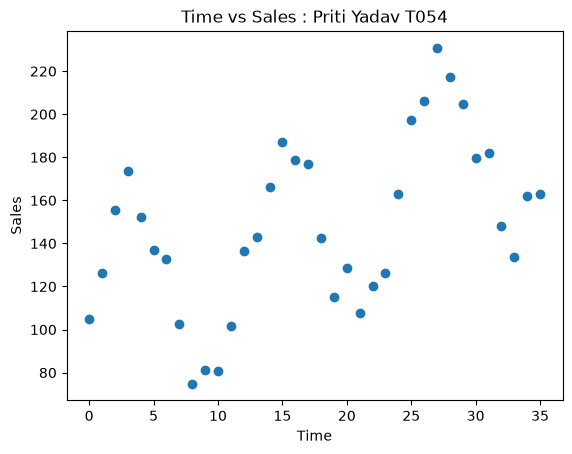


Regression Equation:
Sales = 116.61 + (1.82 × Time)

Predicted Sales for Next Month: 181.95
R2 Score: 0.2377
Mean Squared Error: 1140.34

Actual vs Predicted Sales:
   Actual Sales  Predicted Sales
0    104.967142       116.606715
1    126.474500       118.421834
2    155.492441       120.236952
3    173.801727       122.052071
4    152.388308       123.867190
5    136.944345       125.682309
6    132.934985       127.497428
7    102.674347       129.312546
8     74.861129       131.127665
9     81.139886       132.942784


c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


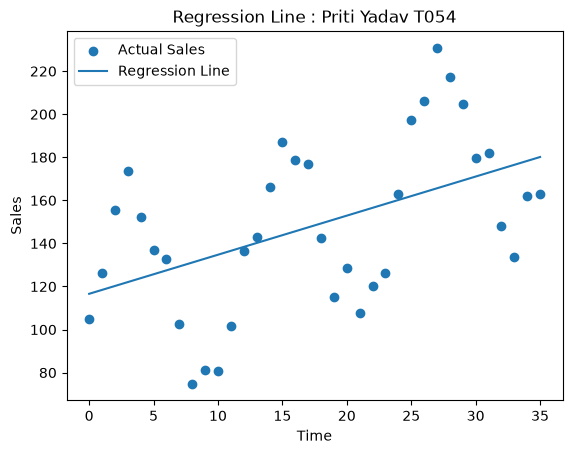

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load the dataset
df = pd.read_csv("sales_data.csv")

# 2. Display first five records
print("First Five Records:")
print(df.head())

# Convert date into datetime
df["date"] = pd.to_datetime(df["date"])

# Create time index
df["Time"] = np.arange(len(df))

# 3 & 4. Independent and dependent variables
X = df[["Time"]]
y = df["Sales"]

# 5. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 6. Scatter plot
plt.scatter(df["Time"], df["Sales"])
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Time vs Sales : Priti Yadav T054")
plt.show()

# 7. Develop linear regression model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# 8. Regression equation
b0 = model.intercept_
b1 = model.coef_[0]

print("\nRegression Equation:")
print(f"Sales = {b0:.2f} + ({b1:.2f} × Time)")

# 9. Predict sales for next time period
next_time = np.array([[len(df)]])
predicted_sales = model.predict(next_time)

print("\nPredicted Sales for Next Month:",
      round(predicted_sales[0], 2))

# 10. R2 score
r2 = r2_score(y, y_pred)
print("R2 Score:", round(r2, 4))

# 11. Mean Squared Error
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", round(mse, 2))

# 12. Actual vs Predicted
comparison = pd.DataFrame({
    "Actual Sales": y,
    "Predicted Sales": y_pred
})

print("\nActual vs Predicted Sales:")
print(comparison.head(10))

# 13. Regression line
plt.scatter(df["Time"], y, label="Actual Sales")
plt.plot(df["Time"], y_pred, label="Regression Line")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Regression Line : Priti Yadav T054")
plt.legend()
plt.show()

First Five Records:
                 Sales
date                  
2020-01-01  104.967142
2020-02-01  126.474500
2020-03-01  155.492441
2020-04-01  173.801727
2020-05-01  152.388308


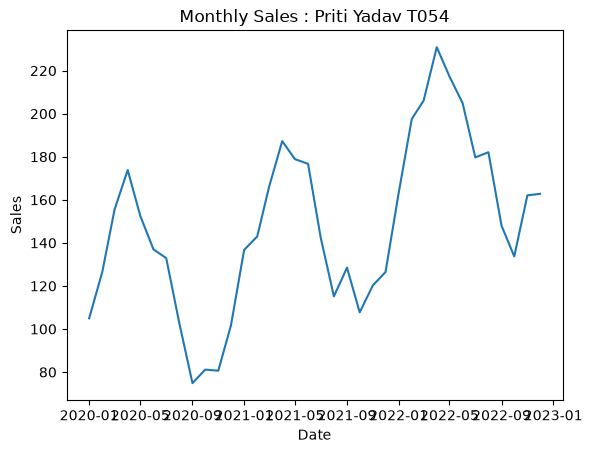


Trend:
The sales data shows an overall increasing trend with monthly fluctuations.

Exponential Smoothing:
MAE: 55.61
MSE: 3504.21

ARIMA:
MAE: 34.41
MSE: 1432.15


c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


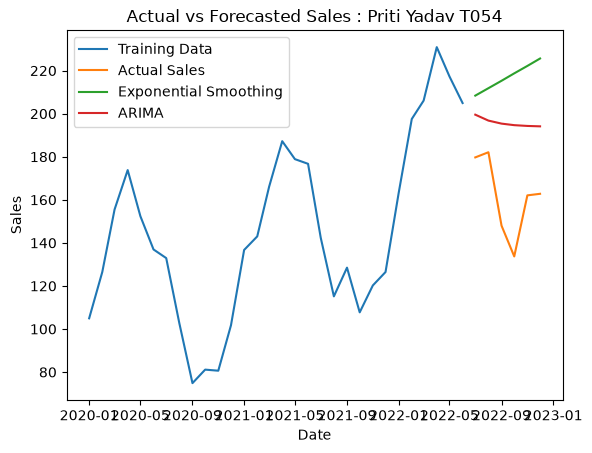


Model Comparison:
Exponential Smoothing MAE: 55.61
ARIMA MAE: 34.41
Exponential Smoothing MSE: 3504.21
ARIMA MSE: 1432.15

ARIMA has the lower forecasting error.

Next 3 Months Forecast:

Exponential Smoothing:
2023-01-01    164.443693
2023-02-01    166.095822
2023-03-01    167.747951
Freq: MS, dtype: float64

ARIMA:
2023-01-01    164.264747
2023-02-01    164.972970
2023-03-01    165.313442
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mvluc\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 16. Load monthly sales data
df = pd.read_csv("sales_data.csv")

# 17. Convert date column into date format
df["date"] = pd.to_datetime(df["date"])

# Sort by date
df = df.sort_values("date")

# Set date as index
df.set_index("date", inplace=True)

sales = df["Sales"]

print("First Five Records:")
print(df.head())

# 18. Plot monthly sales
plt.plot(sales)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Monthly Sales : Priti Yadav T054")
plt.show()

# 19. Observe the trend
print("\nTrend:")
print("The sales data shows an overall increasing trend with monthly fluctuations.")

# Split data for model evaluation
train = sales.iloc[:-6]
test = sales.iloc[-6:]

# ------------------------------------------------
# 20. Exponential Smoothing
# ------------------------------------------------

ets_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

# 21. Forecast next 6 months for evaluation
ets_pred = ets_model.forecast(6)

# Calculate error
ets_mae = mean_absolute_error(test, ets_pred)
ets_mse = mean_squared_error(test, ets_pred)

print("\nExponential Smoothing:")
print("MAE:", round(ets_mae, 2))
print("MSE:", round(ets_mse, 2))

# ------------------------------------------------
# 24. ARIMA
# ------------------------------------------------

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
).fit()

# 25. Forecast
arima_pred = arima_model.forecast(6)

# Calculate error
arima_mae = mean_absolute_error(test, arima_pred)
arima_mse = mean_squared_error(test, arima_pred)

print("\nARIMA:")
print("MAE:", round(arima_mae, 2))
print("MSE:", round(arima_mse, 2))

# ------------------------------------------------
# 22. Plot actual and forecasted sales
# ------------------------------------------------

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Sales")
plt.plot(test.index, ets_pred, label="Exponential Smoothing")
plt.plot(test.index, arima_pred, label="ARIMA")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Forecasted Sales : Priti Yadav T054")
plt.legend()
plt.show()

# ------------------------------------------------
# 26 & 27. Compare models
# ------------------------------------------------

print("\nModel Comparison:")
print("Exponential Smoothing MAE:", round(ets_mae, 2))
print("ARIMA MAE:", round(arima_mae, 2))

print("Exponential Smoothing MSE:", round(ets_mse, 2))
print("ARIMA MSE:", round(arima_mse, 2))

# ------------------------------------------------
# 28. Identify model with lower error
# ------------------------------------------------

if arima_mae < ets_mae:
    print("\nARIMA has the lower forecasting error.")
else:
    print("\nExponential Smoothing has the lower forecasting error.")

# ------------------------------------------------
# Forecast next 3 months using full dataset
# ------------------------------------------------

final_ets = ExponentialSmoothing(
    sales,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

final_arima = ARIMA(
    sales,
    order=(1, 1, 1)
).fit()

ets_future = final_ets.forecast(3)
arima_future = final_arima.forecast(3)

print("\nNext 3 Months Forecast:")
print("\nExponential Smoothing:")
print(ets_future)

print("\nARIMA:")
print(arima_future)
